<a href="https://colab.research.google.com/github/enjomcoding/Time-Series-Forecasting/blob/main/Time_Series_Forecast_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Time Series Forecasting Using LSTM**
* This project performs time series forecasting on the International Airline Passengers dataset, which contains monthly counts of international airline passengers from January 1949 to December 1960.
* The dataset exhibits both trend and seasonality patterns typical in real-world time series data.

# **Step 1: Import Libraries**
This step imports all the necessary Python libraries for data manipulation, visualization, model building, and evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# **Step 2: Load Dataset**
This step loads the International Airline Passengers dataset, which contains monthly counts of international airline passengers from 1949 to 1960. The 'Month' column is converted to datetime format and set as the index for easier time-series handling.

Dataset head:
             Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB

Dataset info:
 None


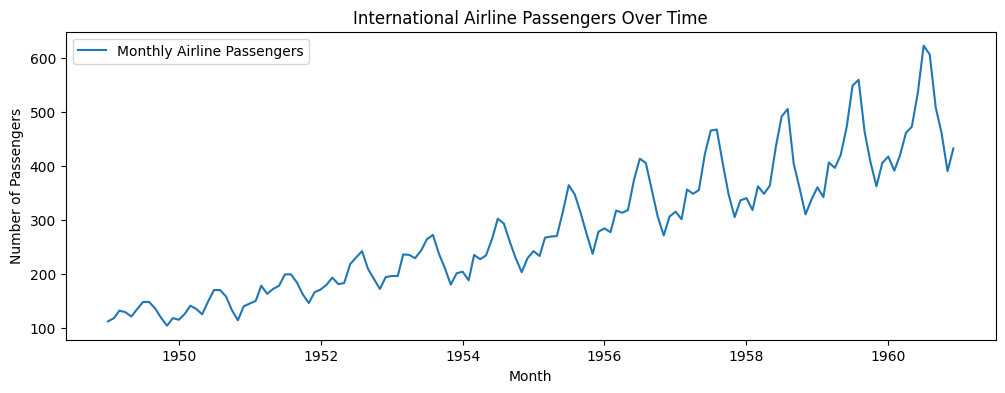

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

print("Dataset head:\n", df.head())
print("\nDataset info:\n", df.info())

# Plot original data
plt.figure(figsize=(12,4))
plt.plot(df, label='Monthly Airline Passengers')
plt.title("International Airline Passengers Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

# **Step 3: Data Preprocessing**
This step scales the passenger data to the range [0,1] using MinMaxScaler, which improves LSTM performance. It also creates input-output sequences for the LSTM, where each sequence of 12 months predicts the next month.

In [ ]:
# normalize data
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(df[['Passengers']])

# lookback = 12 months
def create_sequences(data, lookback=12):
    X, y = [], []
    for i in range(len(data)-lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

lookback = 24
X, y = create_sequences(data_scaled, lookback)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

# split into train and test
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("\nTraining samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Shape of X: (120, 24, 1)
Shape of y: (120, 1)

Training samples: 96
Test samples: 24


# **Step 4: Build LSTM Model**
This step builds an LSTM model using TensorFlow Keras. The model has one LSTM layer with 50 units, a dropout layer to prevent overfitting, and a dense output layer to predict the next month's passenger count.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ---------------------------
# BUILD IMPROVED MODEL
# ---------------------------
model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True, activation='tanh',
                       kernel_regularizer='l2', recurrent_regularizer='l2'),
                 input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64, return_sequences=False, activation='tanh'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 256)        │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,849 (870.50 KB)

 Trainable params: 222,209 (868.00 KB)

 Non-trainable params: 640 (2.50 KB)

# **Step 5: Train LSTM Model**
This step trains the LSTM model on the training set for 150 epochs, using 10% of the training data as a validation set.

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 420ms/step - loss: 3.4246 - val_loss: 2.6986 - learning_rate: 0.0010
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 2.6134 - val_loss: 2.4896 - learning_rate: 0.0010
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 2.3206 - val_loss: 2.3087 - learning_rate: 0.0010
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 2.1603 - val_loss: 2.1519 - learning_rate: 0.0010
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 2.0105 - val_loss: 2.0039 - learning_rate: 0.0010
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 1.8197 - val_loss: 1.8675 - learning_rate: 0.0010
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 1.7165 - val_loss: 1.7436 - learning_rate: 0.0010
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 1.5703 - val_loss: 1.6359 - learning_rate: 0.0010
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 1.4179 - val_loss: 1.5401 - learning_rate: 0.0010
Epoch 10/200
3/3 ━━

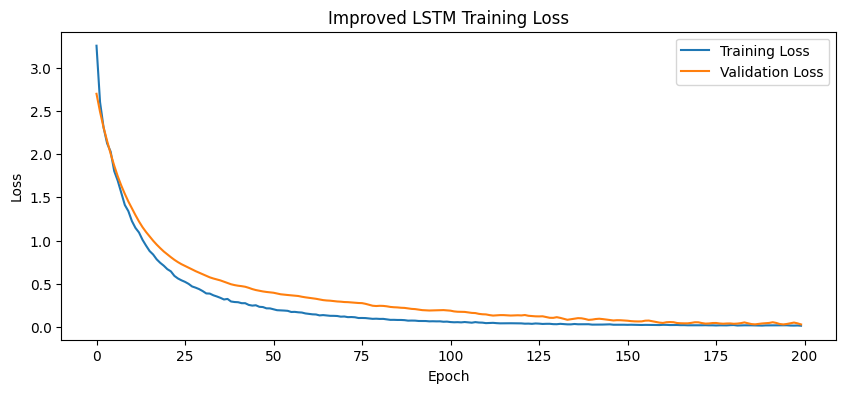

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Improved LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# **Step 6: Evaluate Model**
This step predicts passenger counts on the test set, reverses the scaling calculates RMSE as a performance metric, and plots actual vs predicted values.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step

Root Mean Squared Error (RMSE): 82.52432035556791


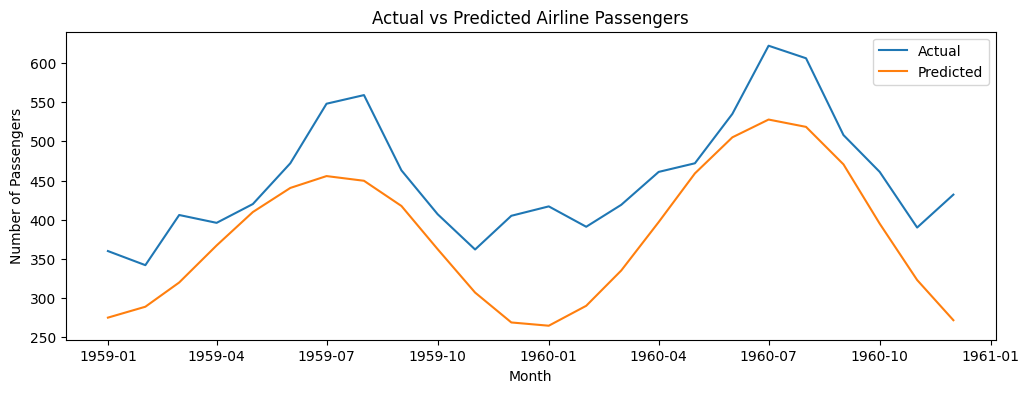

In [ ]:
y_pred = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred)
y_test_real = scaler.inverse_transform(y_test)


rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
print("\nRoot Mean Squared Error (RMSE):", rmse)

plt.figure(figsize=(12,4))
plt.plot(df.index[-len(y_test_inv):], y_test_inv, label='Actual')
plt.plot(df.index[-len(y_test_inv):], y_pred_inv, label='Predicted')
plt.title('Actual vs Predicted Airline Passengers')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

# **Step 7: Sample Predictions**
Prints a few actual and predicted passenger counts for inspection.

In [ ]:
for i in range(5):
    actual = y_test_inv[i][0]
    predicted = y_pred_inv[i][0]
    print(f"Month: {df.index[-len(y_test_inv)+i].date()}, Actual: {actual:.0f}, Predicted: {predicted:.0f}")

Month: 1959-01-01, Actual: 360, Predicted: 275
Month: 1959-02-01, Actual: 342, Predicted: 289
Month: 1959-03-01, Actual: 406, Predicted: 320
Month: 1959-04-01, Actual: 396, Predicted: 367
Month: 1959-05-01, Actual: 420, Predicted: 410


# **Sample Forcast**
This step uses the trained model to forecast passenger counts for the next 12 months. It iteratively predicts one month at a time, appends it to the sequence, and continues.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


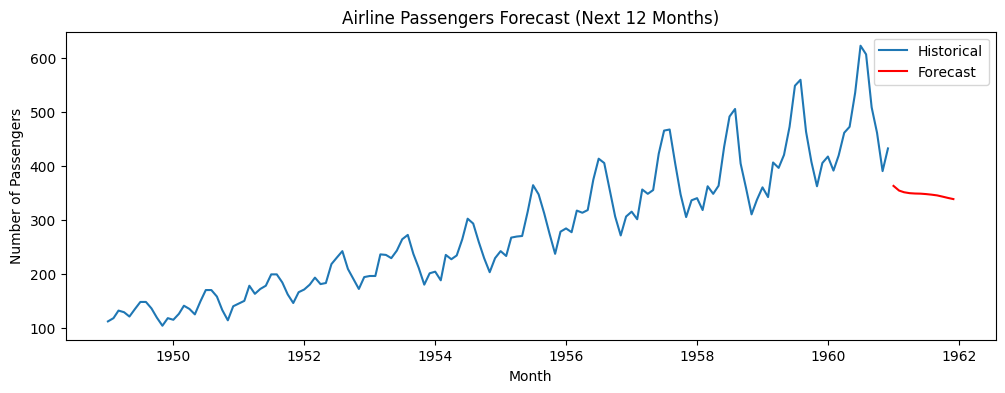


Forecasted Airline Passengers for Next 12 Months:
1961-01-01: 363
1961-02-01: 354
1961-03-01: 351
1961-04-01: 349
1961-05-01: 349
1961-06-01: 348
1961-07-01: 348
1961-08-01: 346
1961-09-01: 345
1961-10-01: 343
1961-11-01: 340
1961-12-01: 338


In [ ]:
# forecast next 12 months
forecast_steps = 12
last_sequence = data_scaled[-lookback:]
forecast = []

current_seq = last_sequence.copy()
for _ in range(forecast_steps):
    pred = model.predict(current_seq.reshape(1, lookback, 1))
    forecast.append(pred[0,0])
    current_seq = np.append(current_seq[1:], pred, axis=0)

# inverse transform
forecast_inv = scaler.inverse_transform(np.array(forecast).reshape(-1,1))

# create future date index
future_dates = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')

# plot forecast
plt.figure(figsize=(12,4))
plt.plot(df, label='Historical')
plt.plot(future_dates, forecast_inv, label='Forecast', color='red')
plt.title('Airline Passengers Forecast (Next 12 Months)')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

# print
print("\nForecasted Airline Passengers for Next 12 Months:")
for date, value in zip(future_dates, forecast_inv):
    print(f"{date.date()}: {value[0]:.0f}")